# Graphviz Review Notebook

This notebook covers:
1. Import/Export graph and files
2. Drawing trees and graphs
3. BFS and DFS visualization (step-by-step animation)


In [2]:
# Install graphviz if needed
%pip install graphviz

from graphviz import Digraph, Graph

Note: you may need to restart the kernel to use updated packages.


## 1. Import / Export Graph

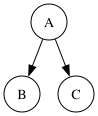

In [4]:
# Create a graph and export to file
g = Digraph('MyGraph', format='png')
g.attr('node', shape='circle')

g.node('A')
g.node('B')
g.node('C')

g.edge('A', 'B')
g.edge('A', 'C')

# Save graph to file
g.render('graph.txt',view=False)

g

### Import graph from DOT file

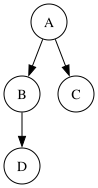

In [5]:
# Example DOT string (simulate reading from file)
from graphviz import Source

dot_data = '''
digraph G {
    node [shape=circle]
    A -> B;
    A -> C;
    B -> D;
}
'''

g2 = Source(dot_data)
g2

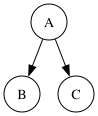

In [6]:
# Create a graph from a DOT file
from graphviz import Source

g = Source.from_file('graph.txt')
g

## 2. Drawing Tree / Graph

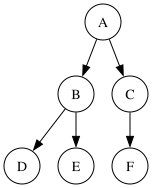

In [7]:
# Draw a tree
tree = Digraph('Tree', node_attr={'shape': 'circle'})

tree.edges([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F')
])

tree

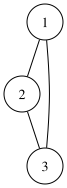

In [8]:
# Undirected graph
g3 = Graph('Undirected', node_attr={'shape': 'circle'})
g3.edge('1', '2')
g3.edge('2', '3')
g3.edge('3', '1')

g3

## 3. BFS Visualization (Step-by-step)

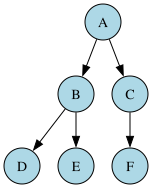

In [9]:
# BFS animation using multiple frames

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def draw_bfs_step(visited):
    dot = Digraph(node_attr={'shape': 'circle'})
    for node in graph:
        color = 'lightblue' if node in visited else 'white'
        dot.node(node, style='filled', fillcolor=color)
    for u in graph:
        for v in graph[u]:
            dot.edge(u, v)
    return dot

from collections import deque

def bfs(start):
    visited = []
    queue = deque([start])

    steps = []

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            steps.append(draw_bfs_step(visited.copy()))
            for neighbor in graph[node]:
                queue.append(neighbor)

    return steps

bfs_steps = bfs('A')

from IPython.display import display, clear_output
import time

def animate(steps, delay=1):
    for step in steps:
        clear_output(wait=True)  # xóa frame trước
        display(step)            # hiển thị frame mới
        time.sleep(delay)        # dừng 1 chút

animate(bfs_steps, delay=1)

## 4. DFS Visualization (Step-by-step)

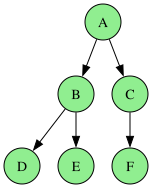

In [10]:
def draw_dfs_step(visited):
    dot = Digraph(node_attr={'shape': 'circle'})
    for node in graph:
        color = 'lightgreen' if node in visited else 'white'
        dot.node(node, style='filled', fillcolor=color)
    for u in graph:
        for v in graph[u]:
            dot.edge(u, v)
    return dot

def dfs(node, visited, steps):
    if node not in visited:
        visited.append(node)
        steps.append(draw_dfs_step(visited.copy()))
        for neighbor in graph[node]:
            dfs(neighbor, visited, steps)

def run_dfs(start):
    visited = []
    steps = []
    dfs(start, visited, steps)
    return steps

dfs_steps = run_dfs('A')
# dfs_steps[0]

from IPython.display import display, clear_output
import time

def animate(steps, delay=1):
    for step in steps:
        clear_output(wait=True)  # xóa frame trước
        display(step)            # hiển thị frame mới
        time.sleep(delay)        # dừng 1 chút

animate(dfs_steps, delay=1)

### Export to an animated gif

In [11]:
# install packages
%pip install imageio pillow

Note: you may need to restart the kernel to use updated packages.


In [12]:
import imageio.v2 as imageio
import os

def export_gif(frames, filename="animation.gif", duration=1):
    images = []

    for i, frame in enumerate(frames):
        filepath = f"temp_frame_{i}"

        # render ra PNG
        frame.render(filepath, format='png', cleanup=True)

        # đọc ảnh
        img = imageio.imread(f"{filepath}.png")
        images.append(img)

        # xóa file tạm
        os.remove(f"{filepath}.png")

    # tạo GIF
    imageio.mimsave(filename, images, duration=duration)
    
# export to gif    
dfs_frames = run_dfs('A')
export_gif(dfs_frames, "dfs.gif", duration=5)